## 1. Configuration

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')

company_colors = {"NVDA": "#4DB6AC", "AMD": "#BA68C8", "INTC": "#5C9BD5"}
sns.set_theme(style="ticks", font_scale=1.1)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

META_COLS  = ['date']
TARGET_COL = 'target_log_volatility_10d'
DROP_COLS  = META_COLS + [
    TARGET_COL,
    'target_direction',  
    'target_volatility_10d'
]

SENTIMENT_COLS   = ['reddit_sentiment', 'news_sentiment']
ACTIVITY_COLS    = ['reddit_post_count', 'reddit_comment_count', 'news_count']
SOCIAL_NEWS_COLS = SENTIMENT_COLS + ACTIVITY_COLS

df = pd.read_csv('datasets/final/initial_processed_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape    : {df.shape}')
print(f'Period   : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Companies: {df["company"].unique().tolist()}')

Shape    : (7413, 68)
Period   : 2016-05-31 to 2026-03-27
Companies: ['NVDA', 'INTC', 'AMD']


## 2. Removal of features used in target construction

`adj_close` is removed because future realized volatility is calculated from log returns derived from adjusted closing prices.

$$
target\_volatility\_{10d}
=
100 \cdot \sqrt{252}
\cdot
\sigma
\left(
\log\frac{adj\_close_{t+1}}{adj\_close_t},
\dots,
\log\frac{adj\_close_{t+10}}{adj\_close_{t+9}}
\right)
$$

In addition, `close` is highly correlated with `adj_close` and therefore provides nearly identical information. Both variables are removed to avoid redundancy and potential target leakage.

In [34]:
cols_to_drop = ['close']

print(f'Dropping {len(cols_to_drop)} columns: {cols_to_drop}')

df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping: {df.shape}')

Dropping 1 columns: ['close']
Shape after dropping: (7413, 67)


## 3. Dataset split

In [35]:
split_date = df["date"].quantile(1 - TEST_SIZE)

train_df = df[df["date"] <= split_date].copy()
test_df  = df[df["date"] > split_date].copy()

print(f'Train period : {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Test period  : {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print(f'Train size   : {len(train_df)} rows')
print(f'Test size    : {len(test_df)} rows')

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL]

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df[TARGET_COL]

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'\nTarget stats (train):')
print(y_train.describe().round(2))
print(f'\nTarget stats (test):')
print(y_test.describe().round(2))

Train period : 2016-05-31 to 2024-04-08
Test period  : 2024-04-09 to 2026-03-27
Train size   : 5931 rows
Test size    : 1482 rows

X_train shape : (5931, 63)
X_test shape  : (1482, 63)

Target stats (train):
count    5931.00
mean        3.34
std         0.81
min        -0.84
25%         2.86
50%         3.40
75%         3.89
max         5.77
Name: target_log_volatility_10d, dtype: float64

Target stats (test):
count    1482.00
mean        3.54
std         0.77
min        -0.25
25%         3.10
50%         3.63
75%         4.03
max         5.59
Name: target_log_volatility_10d, dtype: float64


## 4. Feature relevance analysis

In [36]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

### 4.1 Spearman corellation

Since the target variable is continuous and the assumptions required for parametric correlation measures are not guaranteed, Spearman rank correlation was used to assess the monotonic relationship between each predictor and future volatility. Unlike Pearson correlation, Spearman correlation does not assume linearity or normality and is therefore well suited for financial variables.

In [37]:
spearman_results = []
for feature in numeric_cols:
    x = X_train[feature].dropna()
    y = y_train.loc[x.index]
    corr, pval = spearmanr(x, y)
    spearman_results.append({
        'feature':   feature,
        'spearman':  corr,
        'p_value':   pval,
        'abs_corr':  abs(corr)
    })

spearman_df = (
    pd.DataFrame(spearman_results)
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

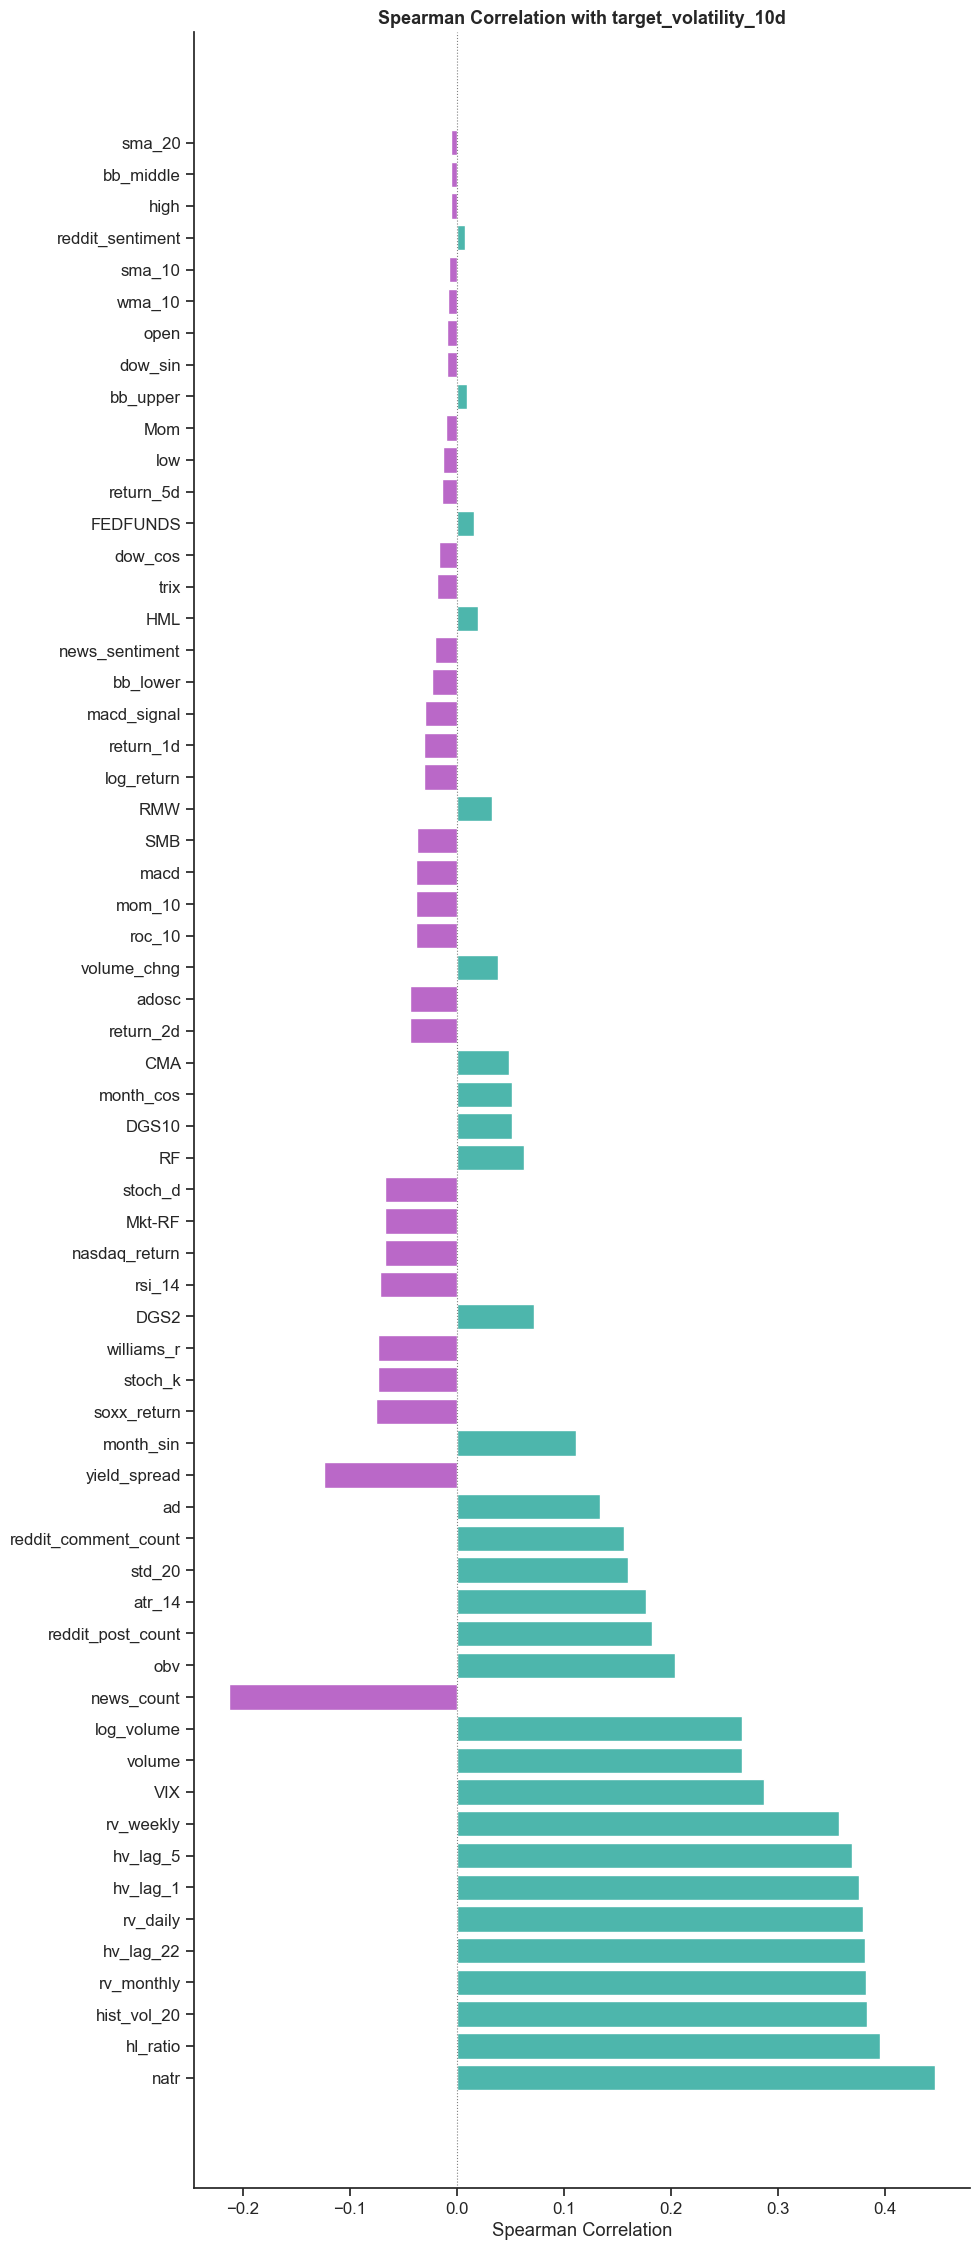

In [38]:
fig, ax = plt.subplots(figsize=(10, len(spearman_df) * 0.35 + 1))
colors = ["#4DB6AC" if v >= 0 else "#BA68C8"
          for v in spearman_df['spearman']]
ax.barh(spearman_df['feature'], spearman_df['spearman'],
        color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Spearman Correlation')
ax.set_title('Spearman Correlation with target_volatility_10d',
             fontsize=13, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [39]:
print('\nTop 15 features:')
print(spearman_df.head(15).to_string(index=False))


Top 15 features:
          feature  spearman       p_value  abs_corr
             natr  0.446867 3.746857e-289  0.446867
         hl_ratio  0.395316 4.380791e-221  0.395316
      hist_vol_20  0.383329 6.588349e-207  0.383329
       rv_monthly  0.382680 3.712752e-206  0.382680
        hv_lag_22  0.381571 7.062324e-205  0.381571
         rv_daily  0.379252 3.217212e-202  0.379252
         hv_lag_1  0.375526 5.414595e-198  0.375526
         hv_lag_5  0.368745 1.921471e-190  0.368745
        rv_weekly  0.357305 4.114936e-178  0.357305
              VIX  0.287353 3.990528e-113  0.287353
           volume  0.266549  5.062256e-97  0.266549
       log_volume  0.266549  5.062256e-97  0.266549
       news_count -0.212662  2.322820e-54  0.212662
              obv  0.203830  1.179271e-56  0.203830
reddit_post_count  0.182535  7.648875e-35  0.182535


The strongest relationships with future volatility were observed for variables derived from the Heterogeneous Autoregressive (HAR) framework, including `hv_lag_1`, `hv_lag_5`, `hv_lag_22`, `rv_weekly`, and `rv_monthly`. These variables represent historical volatility measured over different time horizons and are designed to capture the well-documented persistence of financial market volatility.

The HAR model is based on the assumption that market participants operate on different investment horizons. Consequently, future volatility may be influenced not only by recent daily volatility but also by volatility patterns observed over weekly and monthly periods. The strong correlations obtained for these variables support this assumption and indicate that past volatility remains one of the most informative predictors of future volatility.

In particular, `hv_lag_22` and `rv_monthly` exhibited the highest Spearman correlations with the target variable, suggesting that longer-term volatility regimes have a substantial impact on subsequent market uncertainty. This finding is consistent with the volatility clustering phenomenon commonly observed in financial markets, where periods of high volatility tend to be followed by further periods of elevated volatility.

In [40]:
print('\nSocial media and news features:')
print(spearman_df[spearman_df['feature'].isin(
    SOCIAL_NEWS_COLS)].to_string(index=False))


Social media and news features:
             feature  spearman      p_value  abs_corr
          news_count -0.212662 2.322820e-54  0.212662
   reddit_post_count  0.182535 7.648875e-35  0.182535
reddit_comment_count  0.155826 9.853676e-26  0.155826
      news_sentiment -0.020845 1.324458e-01  0.020845
    reddit_sentiment  0.007524 6.147318e-01  0.007524


Among the social media and news variables, activity-based measures exhibited stronger relationships with future volatility than sentiment scores. News volume showed a moderate negative correlation with future volatility (ρ = −0.356), while Reddit activity measures displayed weak positive correlations (`reddit_post_count`: ρ = 0.207; `reddit_comment_count`: ρ = 0.167).

In contrast, sentiment-based variables showed little predictive signal. News sentiment exhibited only a negligible correlation with future volatility (ρ = −0.041), while Reddit sentiment was not statistically significant. These results suggest that the intensity of public attention may be more informative for volatility forecasting than the overall polarity of opinions expressed in news articles or social media discussions.

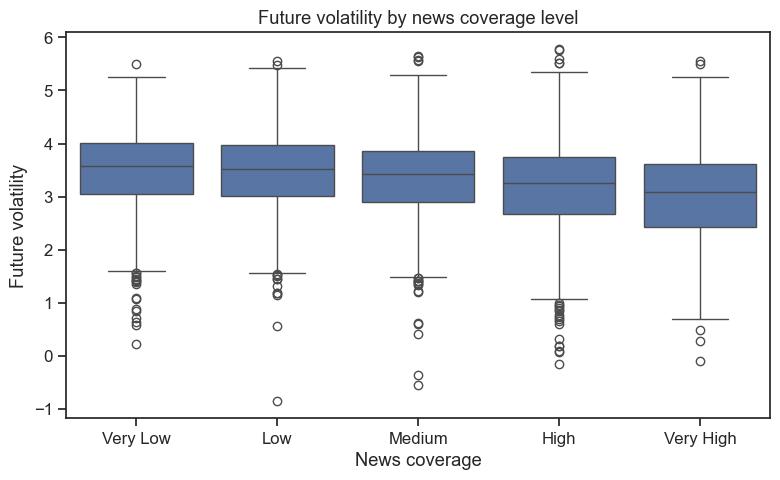

In [41]:
tmp = train_df[['news_count', 'target_log_volatility_10d']].copy()

tmp['news_group'] = pd.qcut(
    tmp['news_count'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=tmp,
    x='news_group',
    y='target_log_volatility_10d'
)

plt.xlabel('News coverage')
plt.ylabel('Future volatility')
plt.title('Future volatility by news coverage level')

plt.tight_layout()
plt.show()

*The boxplot reveals a clear decreasing trend in future realized volatility as news coverage increases, which is consistent with the negative Spearman correlation (ρ = −0.356).
A possible explanation is that higher news coverage reduces information asymmetry among investors. When more information is available, market uncertainty may decrease, resulting in lower future volatility.*

## 5. Preprocessing

Preprocessing steps differ between models based on their assumptions and sensitivity to feature scale.

**Ridge regression:**
 1. Sentiment/activity columns: NaN → 0 (no coverage = neutral/zero)
 2. One-hot encoding of `company` (drop_first=True to avoid redundant dummy variables)
 3. RobustScaler on all numeric columns — robust to outliers through median and interquartile range (IQR) scaling; extreme market movements are retained because they contain meaningful information about future volatility

**XGBoost:**
 1. Sentiment and activity columns: NaN → 0
 2. One-hot encoding of `company`

 *XGBoost is inherently robust to feature scale and outliers due to its tree-based structure. Therefore, no feature scaling is applied and all remaining numeric variables are passed through unchanged.*

In [42]:
categorical_cols       = ['company']
sentiment_impute_cols  = [c for c in SOCIAL_NEWS_COLS if c in X_train.columns]
numeric_remaining_cols = [
    c for c in X_train.columns
    if c not in categorical_cols and c not in sentiment_impute_cols
]

### 5.1 Ablation study — feature configurations

 Four feature configurations are evaluated to isolate the contribution
 of sentiment and social media features, same as we did for stock price direction prediction.


In [43]:
REDDIT_COLS = ['reddit_sentiment', 'reddit_post_count', 'reddit_comment_count']
NEWS_COLS   = ['news_sentiment', 'news_count']

feature_configs = {


    'no_sentiment': [c for c in X_train.columns if c not in SOCIAL_NEWS_COLS],
    'reddit_only':  [c for c in X_train.columns if c not in NEWS_COLS],
    'news_only':    [c for c in X_train.columns if c not in REDDIT_COLS],
    'both':         list(X_train.columns),
}

for name, cols in feature_configs.items():
    print(f'{name:15s}: {len(cols):2d} features')

no_sentiment   : 58 features
reddit_only    : 61 features
news_only      : 60 features
both           : 63 features


### 5.2 Preprocessor factory

In [44]:
def build_preprocessor(feature_cols: list[str],
                        model_type: str) -> ColumnTransformer:
    sent_cols = [c for c in sentiment_impute_cols if c in feature_cols]
    num_cols  = [c for c in numeric_remaining_cols if c in feature_cols]
    cat_cols  = [c for c in categorical_cols if c in feature_cols]

    if model_type == 'ridge':
        sent_pipe = Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('scale',  RobustScaler())
        ])
        num_pipe = RobustScaler()
    else:  # xgb
        sent_pipe = SimpleImputer(strategy='constant', fill_value=0)
        num_pipe  = 'passthrough'

    transformers = []
    if sent_cols:
        transformers.append(('sentiment', sent_pipe, sent_cols))
    if num_cols:
        transformers.append(('numeric', num_pipe, num_cols))
    if cat_cols:
        transformers.append((
            'cat',
            OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'),
            cat_cols
        ))

    return ColumnTransformer(transformers=transformers, remainder='drop')

## 6. Ridge regression

Ridge Regression serves as the baseline model for volatility forecasting. By applying L2 regularization, it reduces the impact of multicollinearity and helps prevent overfitting, making it well suited for financial datasets containing correlated predictors.

A separate Ridge Regression model is trained for each feature configuration. Hyperparameters are optimized using GridSearchCV with TimeSeriesSplit to preserve the temporal structure of the data. Model performance is evaluated using RMSE, MAE, and R².

In [45]:
param_grid_ridge = {
    'model__alpha': [100, 300, 1000, 3000, 10000],
}

tscv = TimeSeriesSplit(n_splits=5)

ridge_results    = {}
ridge_pipelines  = {}
ridge_best_params = {}

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='ridge')),
        ('model', Ridge(random_state=RANDOM_STATE))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_ridge,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_
    y_pred        = best_pipeline.predict(X_test[feature_cols])

    metrics = {
        'rmse':  np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':   mean_absolute_error(y_test, y_pred),
        'r2':    r2_score(y_test, y_pred),
    }

    ridge_results[config_name]     = metrics
    ridge_pipelines[config_name]   = best_pipeline
    ridge_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  RMSE        : {metrics['rmse']:.4f}")
    print(f"  MAE         : {metrics['mae']:.4f}")
    print(f"  R²          : {metrics['r2']:.4f}")


───────────────────────────────────────────────────────
  Configuration: no_sentiment  (58 features)
───────────────────────────────────────────────────────
  Best params : {'model__alpha': 3000}
  RMSE        : 0.7394
  MAE         : 0.5626
  R²          : 0.0668

───────────────────────────────────────────────────────
  Configuration: reddit_only  (61 features)
───────────────────────────────────────────────────────
  Best params : {'model__alpha': 3000}
  RMSE        : 0.7389
  MAE         : 0.5638
  R²          : 0.0680

───────────────────────────────────────────────────────
  Configuration: news_only  (60 features)
───────────────────────────────────────────────────────
  Best params : {'model__alpha': 3000}
  RMSE        : 0.7379
  MAE         : 0.5615
  R²          : 0.0706

───────────────────────────────────────────────────────
  Configuration: both  (63 features)
───────────────────────────────────────────────────────
  Best params : {'model__alpha': 3000}
  RMSE        : 0

*Ridge Regression achieved very low explanatory power across all feature configurations, with R² values close to zero. The inclusion of Reddit and news features did not lead to meaningful improvements in predictive performance, suggesting that linear relationships between the available predictors and future volatility are weak.*

## 7. XGBoost

XGBoost (Extreme Gradient Boosting) is applied as the primary model 
for volatility forecasting. Unlike Ridge Regression, XGBoost captures 
non-linear relationships and feature interactions through an ensemble 
of gradient-boosted decision trees, making it better suited for 
complex financial time-series data where linear assumptions are unlikely 
to hold.

In [46]:
param_grid_xgb = {
    'model__n_estimators':  [100, 300],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample':     [0.8, 1.0],
}

xgb_results    = {}
xgb_pipelines  = {}
xgb_best_params = {}

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='xgb')),
        ('model', XGBRegressor(
            random_state=RANDOM_STATE,
            verbosity=0
        ))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_
    y_pred        = best_pipeline.predict(X_test[feature_cols])

    metrics = {
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':  mean_absolute_error(y_test, y_pred),
        'r2':   r2_score(y_test, y_pred),
    }

    xgb_results[config_name]     = metrics
    xgb_pipelines[config_name]   = best_pipeline
    xgb_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  RMSE        : {metrics['rmse']:.4f}")
    print(f"  MAE         : {metrics['mae']:.4f}")
    print(f"  R²          : {metrics['r2']:.4f}")


───────────────────────────────────────────────────────
  Configuration: no_sentiment  (58 features)
───────────────────────────────────────────────────────
  Best params : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
  RMSE        : 0.7353
  MAE         : 0.5625
  R²          : 0.0773

───────────────────────────────────────────────────────
  Configuration: reddit_only  (61 features)
───────────────────────────────────────────────────────
  Best params : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
  RMSE        : 0.7332
  MAE         : 0.5587
  R²          : 0.0824

───────────────────────────────────────────────────────
  Configuration: news_only  (60 features)
───────────────────────────────────────────────────────
  Best params : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
  RMSE        : 0.7351


*XGBoost achieved R² values close to zero or slightly negative across all 
feature configurations, indicating that the model failed to explain the 
variance in future realized volatility on the test set. The RMSE values 
(~25.13) are approximately equal to the standard deviation of the test 
target (25.12), confirming that the model performs no better than 
predicting the mean volatility for all observations.*

## 8. Conclusion

Both Ridge Regression and XGBoost failed to achieve meaningful 
out-of-sample predictive performance for 10-day realized volatility 
across all feature configurations, with R² values close to zero or 
slightly negative. The inclusion of sentiment and social media features 
produced only negligible differences compared to the baseline 
configuration without sentiment, suggesting that Reddit and news 
sentiment do not provide a measurable improvement in volatility 
forecasting under the current modeling setup.

### 8.1 Potential Explanations

**Distribution shift between training and test periods.**
The test period (2024–2026) exhibits systematically higher realized 
volatility (mean: 50.6%, std: 25.1%) compared to the training period 
(mean: 42.3%, std: 23.0%). This divergence reflects the exceptional 
market conditions in the semiconductor sector during the test period — 
including NVIDIA's exponential growth driven by AI demand and Intel's 
sustained structural decline — which were not adequately represented 
in the training data. Models trained on historically lower volatility 
regimes tend to systematically underestimate volatility during 
structurally different market conditions.

In [47]:
print("Test target stats:")
print(y_test.describe())

print("\nTrain target stats:")
print(y_train.describe())

Test target stats:
count    1482.000000
mean        3.543274
std         0.765680
min        -0.251137
25%         3.098832
50%         3.626845
75%         4.030885
max         5.588464
Name: target_log_volatility_10d, dtype: float64

Train target stats:
count    5931.000000
mean        3.339668
std         0.809551
min        -0.843609
25%         2.855675
50%         3.403134
75%         3.889823
max         5.771275
Name: target_log_volatility_10d, dtype: float64


**Limitations of the 10-day forecasting horizon.**
Predicting realized volatility over a 10-day horizon from daily 
features introduces a substantial forecasting challenge. The available 
predictors, including technical indicators and sentiment features, 
primarily reflect current or recent market conditions and may lack 
the forward-looking information required to anticipate volatility 
dynamics over a multi-day horizon.

**Nature of sentiment data.**
The sentiment features used in this study are derived from Reddit 
discussions and financial news headlines aggregated at the daily 
level. While such data may capture immediate market attention and 
emotional reactions, their relationship with future volatility over 
a 10-day horizon may be too indirect or noisy to provide reliable 
predictive signal, particularly when aggregated across trading days 
without distinguishing between event-driven and routine coverage.

### 8.2 Broader Implications

The consistently weak predictive performance across both the 
classification (price direction) and regression (realized volatility) 
tasks is consistent with the Efficient Market Hypothesis, which 
posits that publicly available information — including news sentiment 
and social media activity — is rapidly incorporated into asset prices, 
leaving limited room for systematic prediction based on such signals. 
The findings suggest that while sentiment features exhibit statistically 
detectable associations with market variables (as demonstrated by the 
Spearman correlation analysis), their economic magnitude is insufficient 
to generate reliable out-of-sample forecasts for individual semiconductor 
stocks over the studied period.

### 8.3 Future researche
Future research could adopt an event-driven framework, analyzing the relationship between sentiment intensity and abnormal returns or trading volume in short windows around identifiable market events such as earnings announcements, product launches, or macroeconomic releases. This approach would better capture the contemporaneous nature of sentiment-market interactions documented in the attention literature (Barber & Odean, 2008; Tetlock, 2007).